## Data Analysis of Sample Specimen Transcriptions from Herbonauten

### 1. Quantitative Analysis

In [ ]:
#DEFAULT
import os
#3RD PARTY
import pandas as pd
import plotnine as p9
from pygbif import species

#CUSTOM

In [5]:
columns_of_interest = ['Barcode', 'Family', 'genus', 'taxon', 'country', 'collect_date_begin', 'collector', 'latitude', 'longitude', 'collect_number', 'collect_number_no_info']
herbonauten_path = 'data/herbonauts_data/stratified_sample_catalog_numbers_20251117_103411_selected.csv'

#### 1.1 General Overview

In [6]:
try:
    data = pd.read_csv(herbonauten_path, sep=';', usecols=columns_of_interest) # Problem: Varying separators in the past
except ValueError as e:
    data = pd.read_csv(herbonauten_path, usecols=columns_of_interest)

if 'collect_date_begin' in data.columns:
    data['collect_date_year'] = pd.to_datetime(data['collect_date_begin'], errors='coerce').dt.year # Year extraction from date
    columns_of_interest.append('collect_date_year')

total_records = len(data)
print("\nTotal Records: ", total_records)

variations = {col: data[col].nunique() for col in columns_of_interest if col in data.columns}
for column, variation_count in variations.items():
    print("Column: " + column + ", Number of Variations: " + str(variation_count))

empty_counts = {col: data[col].isnull().sum() for col in columns_of_interest if col in data.columns}
print("\nEmpty records in each column:")
for column, empty_count in empty_counts.items():
    print(f'Column: {column}, Empty Records: {empty_count}, Percentage: {empty_count / total_records:.2%}')

print("\nFirst 100 rows of the dataframe:")
print(data.head(100).to_string())


Total Records:  1838
Column: Barcode, Number of Variations: 1838
Column: Family, Number of Variations: 85
Column: genus, Number of Variations: 365
Column: taxon, Number of Variations: 1024
Column: country, Number of Variations: 141
Column: collect_date_begin, Number of Variations: 1566
Column: collector, Number of Variations: 1022
Column: latitude, Number of Variations: 1603
Column: longitude, Number of Variations: 1603
Column: collect_number, Number of Variations: 895
Column: collect_number_no_info, Number of Variations: 2
Column: collect_date_year, Number of Variations: 195

Empty records in each column:
Column: Barcode, Empty Records: 0, Percentage: 0.00%
Column: Family, Empty Records: 0, Percentage: 0.00%
Column: genus, Empty Records: 0, Percentage: 0.00%
Column: taxon, Empty Records: 0, Percentage: 0.00%
Column: country, Empty Records: 56, Percentage: 3.05%
Column: collect_date_begin, Empty Records: 172, Percentage: 9.36%
Column: collector, Empty Records: 143, Percentage: 7.78%
C

#### 1.2. Distribution of Transcriptions by Year

In [7]:
print("\nDistribution of years in 'collect_date_year' (50-year intervals):")
year_distribution = data['collect_date_year'].dropna().astype(int)
bins = list(range(year_distribution.min() - (year_distribution.min() % 50), year_distribution.max() + 50, 50)) # 50-year bins
year_counts = pd.cut(year_distribution, bins=bins).value_counts().sort_index() # Group existing years and count their occurrences
records_with_years = year_distribution.count()
for interval, count in year_counts.items():
    print(f'Years {interval}: {count} records ({count / records_with_years:.2%} of records with valid years)')
print(f"Total records with valid years: {year_distribution.count()} ({records_with_years / total_records:.2%} of total records)")
print(f'Total records with invalid or missing years: {total_records - year_distribution.count()} ({(total_records - records_with_years) / total_records:.2%} of total records)')
# find minima and maxima
oldest_year = year_distribution.min()
most_recent_year = year_distribution.max()
oldest_records = data[data['collect_date_year'] == oldest_year]['Barcode'].tolist()
most_recent_records = data[data['collect_date_year'] == most_recent_year]['Barcode'].tolist()
print("Oldest records (Year " + str(oldest_year) + "): " + str(oldest_records))
print("Most recent records (Year " +  str(most_recent_year) + "): " + str(most_recent_records))

print("Distribution of years in 'collect_date_year' (before 1970 and 1970 or later):")
print(f'Number of collection dates before 1970: {year_distribution[year_distribution < 1970].count()} ({year_distribution[year_distribution < 1970].count() / records_with_years:.2%} of records with valid years)')
print(f'Number of collection dates in and after 1970: {year_distribution[year_distribution >= 1970].count()} ({year_distribution[year_distribution >= 1970].count() / records_with_years:.2%} of records with valid years)\n')


Distribution of years in 'collect_date_year' (50-year intervals):
Years (1800, 1850]: 38 records (2.28% of records with valid years)
Years (1850, 1900]: 259 records (15.55% of records with valid years)
Years (1900, 1950]: 556 records (33.37% of records with valid years)
Years (1950, 2000]: 695 records (41.72% of records with valid years)
Years (2000, 2050]: 117 records (7.02% of records with valid years)
Total records with valid years: 1666 (90.64% of total records)
Total records with invalid or missing years: 172 (9.36% of total records)
Oldest records (Year 1800): ['B 10 0655248']
Most recent records (Year 2018): ['B 10 1036101']
Distribution of years in 'collect_date_year' (before 1970 and 1970 or later):
Number of collection dates before 1970: 1156 (69.39% of records with valid years)
Number of collection dates in and after 1970: 510 (30.61% of records with valid years)



#### 1.3. Distribution of Transcriptions by Country

In [8]:
print("\nDistribution of records by country:")
country_counts = data['country'].value_counts(dropna=False)
records_with_country = country_counts.sum() - country_counts.get(pd.NA, 0)
for country, count in country_counts.items():
    print(f'Country: {country}, Records: {count} ({count / records_with_country:.3%} of records with country information)')


Distribution of records by country:
Country: Deutschland, Records: 283 (15.397% of records with country information)
Country: Tansania, Records: 130 (7.073% of records with country information)
Country: Griechenland, Records: 115 (6.257% of records with country information)
Country: Südafrika, Records: 91 (4.951% of records with country information)
Country: Brasilien, Records: 59 (3.210% of records with country information)
Country: nan, Records: 56 (3.047% of records with country information)
Country: Italien, Records: 54 (2.938% of records with country information)
Country: Vereinigte Staaten von Amerika, Records: 53 (2.884% of records with country information)
Country: Österreich, Records: 51 (2.775% of records with country information)
Country: Namibia, Records: 49 (2.666% of records with country information)
Country: Australien, Records: 48 (2.612% of records with country information)
Country: Polen, Records: 40 (2.176% of records with country information)
Country: Frankreich, R

#### 1.4. Distribution of Transcriptions by Family

In [9]:
data['Family'] = data['Family'].str.lower()
print("\nDistribution of records by family:")
family_counts = data['Family'].value_counts(dropna=False)
records_with_family = family_counts.sum() - family_counts.get(pd.NA, 0)
for family, count in family_counts.items():
    print(f'Family: {family}, Records: {count} ({count / records_with_family:.3%} of records with family information)')


Distribution of records by family:
Family: apocynaceae, Records: 303 (16.485% of records with family information)
Family: chenopodiaceae, Records: 230 (12.514% of records with family information)
Family: caryophyllaceae, Records: 224 (12.187% of records with family information)
Family: acanthaceae, Records: 221 (12.024% of records with family information)
Family: betulaceae, Records: 148 (8.052% of records with family information)
Family: potamogetonaceae, Records: 114 (6.202% of records with family information)
Family: balsaminaceae, Records: 96 (5.223% of records with family information)
Family: cupressaceae, Records: 84 (4.570% of records with family information)
Family: pinaceae, Records: 82 (4.461% of records with family information)
Family: aizoaceae, Records: 57 (3.101% of records with family information)
Family: restionaceae, Records: 48 (2.612% of records with family information)
Family: droseraceae, Records: 37 (2.013% of records with family information)
Family: ephedraceae,

### 2. Representativity of the Sample
In order to determine how representative the sample is, we compare its composition and characteristics to the representative BDJ benchmark dataset whose publication gives an overview about the dataset's creation guidelines. To some extent, the comparability is limited by the fact that the BDJ dataset record metadata may contain information that is actually not present on the specimen label (interpreted). In contrast, our Herbonauten dataset is limited to the information available on the label, or transparently inferred from it. 

#### 2.1. Temporal Coverage
##### 2.1.1. General presence of years
The publication paper of the BDJ benchmark dataset states that a collection year is present in 82% of the specimen records. With more records having a collection date in the sample dataset, we consider it as representative.

In [10]:
records_with_year = data['collect_date_year'].notnull().sum()
print(f'\nRecords with a collection year: {records_with_year} ({records_with_year / total_records:.2%} of total records)\n')


Records with a collection year: 1666 (90.64% of total records)



##### 2.1.2. Distribution of years


For most institutions, the heatmaps in the BDJ paper mostly show a global peak around 1970. Our sample heatmap shows a similar peak between 1960 and 1980, but also a historically explainable interim minimum in the 1940s, which can also be found for most institutions.

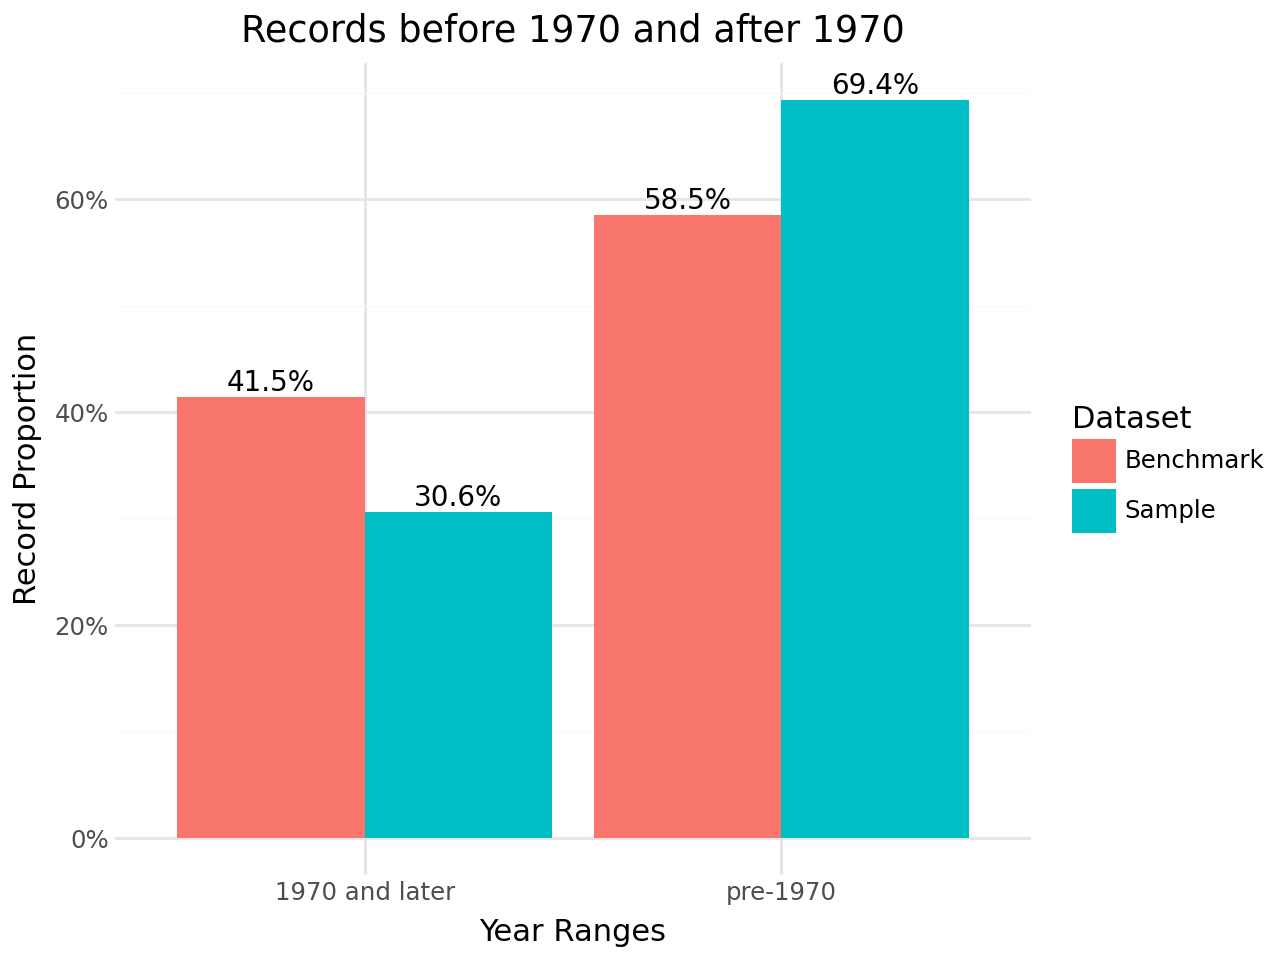

In [14]:
benchmark_dataset = pd.read_excel('./herbarium_images_dataset.xlsx')
benchmark_year_count = {'pre-1970': 0, '1970 and later': 0} # spilt into two groups with the boundary at 1970
for year in benchmark_dataset['year']:
    if not pd.isna(year):
        if year < 1970:
            benchmark_year_count['pre-1970'] += 1
        else:
            benchmark_year_count['1970 and later'] += 1
benchmark_valid_year_counts = sum(benchmark_year_count.values())
benchmark_year_count_relative = dict()
for key, value in benchmark_year_count.items(): # count relative pre-1970 and 1970 and later records
        benchmark_year_count_relative[key] = value / benchmark_valid_year_counts

sample_year_count = {'pre-1970': 0, '1970 and later': 0}
for year in data['collect_date_year']:
    if not pd.isna(year):
        if year < 1970:
            sample_year_count['pre-1970'] += 1
        else:
            sample_year_count['1970 and later'] += 1
sample_valid_year_counts = sum(sample_year_count.values())
sample_year_count_relative = dict()
for key, value in sample_year_count.items():
        sample_year_count_relative[key] = value / sample_valid_year_counts

benchmark_df = pd.DataFrame(list(benchmark_year_count_relative.items()), columns=['Year Range', 'Proportion'])
sample_df = pd.DataFrame(list(sample_year_count_relative.items()), columns=['Year Range', 'Proportion'])
benchmark_df['Dataset'] = 'Benchmark'
sample_df['Dataset'] = 'Sample'
plot = (p9.ggplot(pd.concat([benchmark_df, sample_df]), p9.aes(x='Year Range', y='Proportion', fill='Dataset')) +
        p9.geom_text(p9.aes(label='Proportion'), position=p9.position_dodge(width=0.9), va='bottom', format_string='{:.1%}', size=10) +
        p9.geom_bar(stat='identity', position='dodge') +
        p9.scale_y_continuous(labels=lambda l: ["{:.0%}".format(v) for v in l]) +
        p9.labs(title='Records before 1970 and after 1970', y='Record Proportion', x='Year Ranges') +
        p9.theme_minimal())
plot.show()

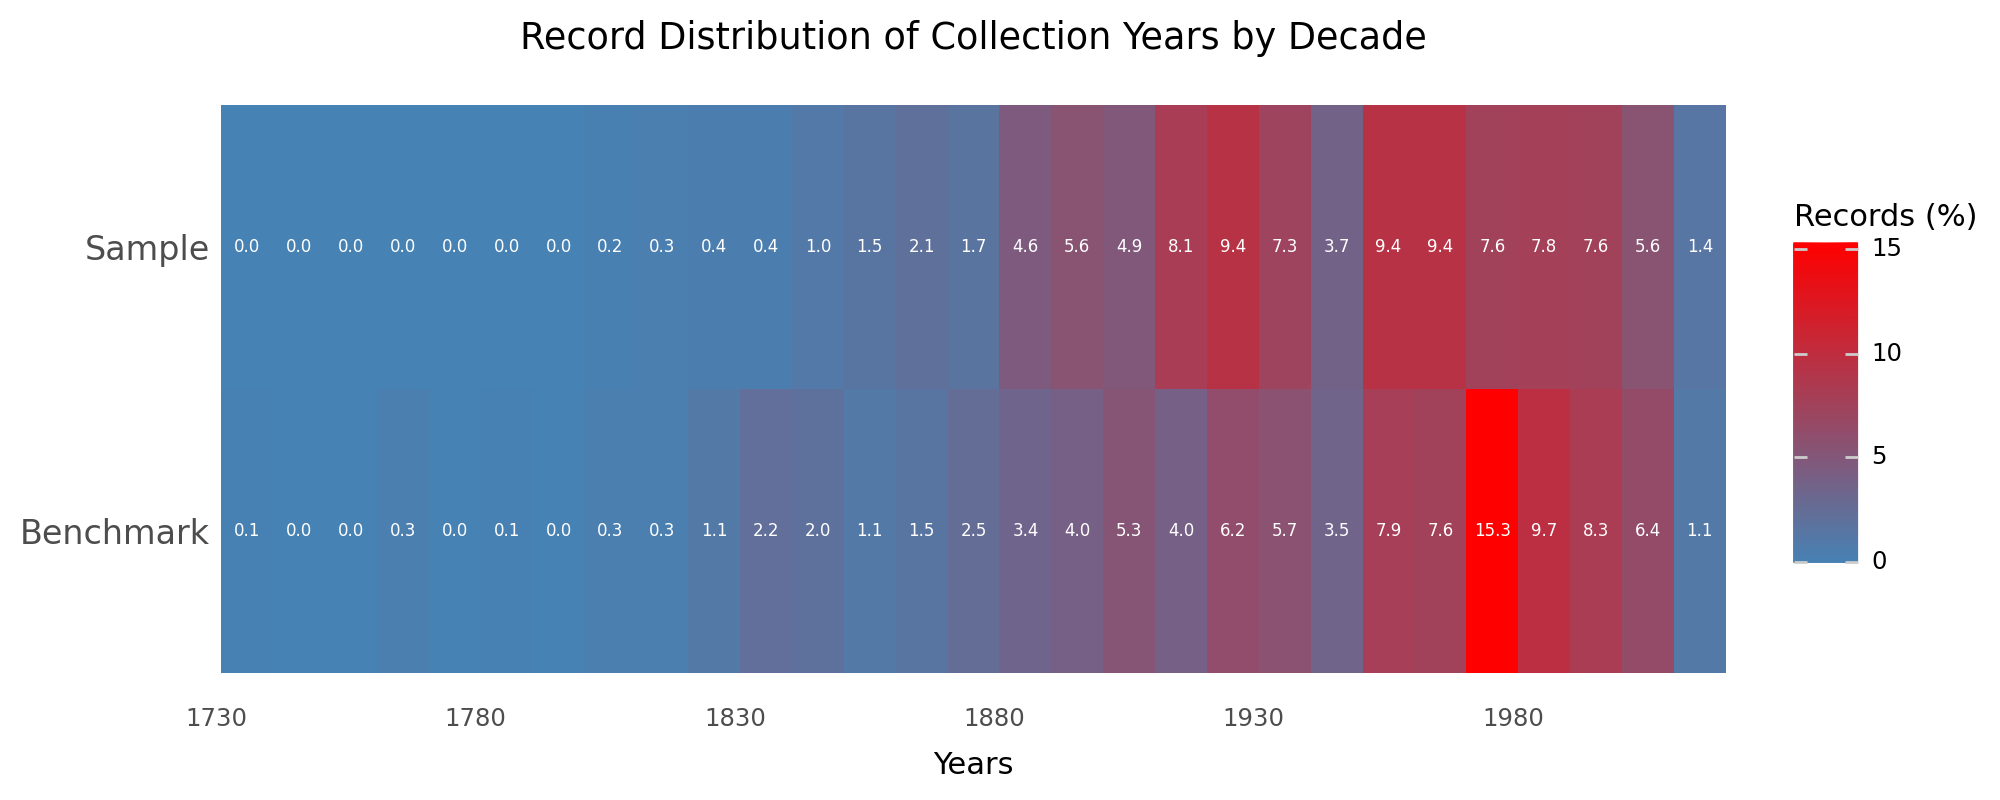

In [15]:
# Further visualization of the year distribution using heatmaps split into decades
valid_dates_benchmark = benchmark_year_count['pre-1970'] + benchmark_year_count['1970 and later']
valid_dates_sample = sample_year_count['pre-1970'] + sample_year_count['1970 and later']
benchmark_decade_counts = pd.cut(benchmark_dataset['year'].dropna(), # the same binning strategy as above but with decades
                                 bins=range(int(benchmark_dataset['year'].min()) - (int(benchmark_dataset['year'].min()) % 10), 
                                            int(benchmark_dataset['year'].max()) + 10, 10)).value_counts().sort_index()
benchmark_decade_counts.index = [f'{interval.left}' for interval in benchmark_decade_counts.index]
benchmark_decade_df = pd.DataFrame({'Decade': benchmark_decade_counts.index.astype(str), 'Count': benchmark_decade_counts.values})
decade_counts = pd.cut(year_distribution, bins=range(year_distribution.min() - (year_distribution.min() % 10), year_distribution.max() + 10, 10)).value_counts().sort_index()
decade_counts.index = [f'{interval.left}' for interval in decade_counts.index] 
decade_df = pd.DataFrame({'Decade': decade_counts.index.astype(str), 'Count': decade_counts.values})
benchmark_decade_df['Count'] = round(benchmark_decade_df['Count'] / valid_dates_benchmark * 100, 1)
decade_df['Count'] = round(decade_df['Count'] / valid_dates_sample * 100, 1)
combined_decade_df = pd.merge(decade_df, benchmark_decade_df, on='Decade', how='outer', suffixes=('_Sample', '_Benchmark')).fillna(0)
combined_decade_heatmap = (p9.ggplot(combined_decade_df.melt(id_vars='Decade', value_vars=['Count_Sample', 'Count_Benchmark'], var_name='Dataset', value_name='Count'), p9.aes(x='Decade', y='Dataset', fill='Count')) +
                            p9.geom_tile() +
                            p9.scale_fill_gradient(low='steelblue', high='red') +
                            p9.theme_minimal() +
                            p9.theme(axis_text_y=p9.element_text(size=12), 
                                     axis_ticks_major_y=p9.element_blank(), 
                                     axis_ticks_minor_y=p9.element_blank(),
                                     axis_ticks_major_x=p9.element_blank(), 
                                     axis_ticks_minor_x=p9.element_blank(), 
                                     panel_grid_major=p9.element_blank(), 
                                     axis_title_y=p9.element_blank(),
                                     axis_text_x=p9.element_text(ha='right'),
                                     figure_size=(10, 4)) +
                            p9.scale_x_discrete(breaks=[str(interval) for i, interval in enumerate(combined_decade_df['Decade']) if i % 5 == 0]) +
                            p9.geom_text(p9.aes(label='Count'), color='white', size=6) +
                            p9.scale_y_discrete(labels={'Count_Sample': 'Sample', 'Count_Benchmark': 'Benchmark'}) +
                            p9.labs(title='Record Distribution of Collection Years by Decade',
                                   x='Years',
                                   fill='Records (%)'))
combined_decade_heatmap.show()

#### 2.2 Taxonomic Coverage
##### 2.2.1. Share of Tracheophyta
In the benchmark dataset, more than 90% of the records belong to the Tracheophyta (vascular plants). For represenativity, the sample dataset should contain around the same share of specimens from this clade.

In [ ]:
def is_tracheophyta(family_name):
    try:
        family_name = family_name.capitalize()
        response = species.name_backbone(name=family_name, rank='family')
        if 'usageKey' in response and 'phylum' in response:
            if response['phylum'].lower() == 'tracheophyta':
                return True, response.get('order')
        return False, None
    except Exception as e:
        print("Error checking family " + family_name + ": " + str(e))
        return False, None
    
tracheophyta_count = 0
tracheophyta_families, tracheophyta_orders = set(), set()
for family in family_counts.index:
    is_tracheo, order = is_tracheophyta(family)
    if pd.notna(family) and is_tracheo:
        if order:
            tracheophyta_orders.add(order)
        tracheophyta_families.add(family)
        tracheophyta_count += family_counts[family]
print(f'\nRecords belonging to Tracheophyta: {tracheophyta_count} ({tracheophyta_count / total_records:.2%} of total records)\n')

Error checking family Apocynaceae: name 'species' is not defined
Error checking family Chenopodiaceae: name 'species' is not defined
Error checking family Caryophyllaceae: name 'species' is not defined
Error checking family Acanthaceae: name 'species' is not defined
Error checking family Betulaceae: name 'species' is not defined
Error checking family Potamogetonaceae: name 'species' is not defined
Error checking family Balsaminaceae: name 'species' is not defined
Error checking family Cupressaceae: name 'species' is not defined
Error checking family Pinaceae: name 'species' is not defined
Error checking family Aizoaceae: name 'species' is not defined
Error checking family Restionaceae: name 'species' is not defined
Error checking family Droseraceae: name 'species' is not defined
Error checking family Ephedraceae: name 'species' is not defined
Error checking family Zingiberaceae: name 'species' is not defined
Error checking family Xyridaceae: name 'species' is not defined
Error checking

##### 2.2.2. Number of Tracheophyta Families and Orders
The benchmark dataset contains 204 families and 58 orders of Tracheophyta while this sample comes with 33 families and 20 orders which is understandable because of the fact that the original dataset consists of records from Herbonauten missions that may be focused on particular familes, which limits the number of orders likewise. In addition, all records are specimens from one institution which may also limit the taxonomic diversity. Hence, we increased the number of families by a weighted sampling.

In [ ]:
print("Number of distinct Tracheophyta families: " + str(len(tracheophyta_families)))
print("Number of distinct Tracheophyta orders: " + str(len(tracheophyta_orders)) + "\n")

Number of distinct Tracheophyta families: 78
Number of distinct Tracheophyta orders: 37



##### 2.2.3. Collector Names
The benchmark dataset contains 1170 unique collector names with different spellings and formats of names possible. In addition, only 6% of the records lack a collector name. The sample dataset shares a similar proportion of collector names.

In [86]:
collector_counts = data['collector'].value_counts(dropna=False)
collector_nones = 0
for collector in collector_counts.index:
    if pd.isna(collector):
        collector_nones += collector_counts[collector]
collector_variations = len(collector_counts) - (1 if collector_nones > 0 else 0)
print(f'Total distinct collectors (excluding empty): {collector_variations}')
print(f'Total records without collector information: {collector_nones} ({collector_nones / total_records:.2%} of total records)')

Total distinct collectors (excluding empty): 1022
Total records without collector information: 143 (7.78% of total records)


##### 2.2.4. Collector Numbers
In the BDJ dataset, 56% of the records contain a collector number or information that no number was assigned. The same information is included in almost 73% of the records in our sample.

In [87]:
collect_data = data[['collect_number', 'collect_number_no_info']]
collect_number_info_count = 0
for collect_number_info in collect_data.iterrows():
    collect_number, collect_number_no_info = collect_number_info[1]['collect_number'], collect_number_info[1]['collect_number_no_info']
    if (type(collect_number) == str) or (pd.notna(collect_number_no_info) and collect_number_no_info == True):
        collect_number_info_count+=1
print(f'{collect_number_info_count} records providing an information about a collector number ({collect_number_info_count / total_records:.2%})')

1458 records providing an information about a collector number (79.33%)


##### 2.2.5. Non-comparable properties
Some characteristics of the benchmark dataset cannot be compared to the sample dataset. For instance, the benchmark dataset contains information if a record is a type specimen or not. Unfortunately, this information is not available in the sample Herbonauten dataset but was one of the key guidelines for selecting specimens for the BDJ benchmark dataset (19% type specimens). 

#### 2.3. Geographic Coverage
According to the BDJ paper of the benchmark dataset, 15% of the records are assigned with coordinates while 94% of the specimens have a country assigned to them. Nine countries are from all continents except Antarctica.
In the sample, more than 90% of the records have a coordinate since citizen scientists were asked to assign coordinates to the specimens based on the locality information although no coordinates do exist on the original specimen labels. 
A massive difference can be observed in the number of countries represented in the sample (141) compared to the benchmark dataset (9). 

In [ ]:
latitude_non_null = data['latitude'].notnull().sum()
print(f'\nRecords with latitude values  : {latitude_non_null} ({latitude_non_null / total_records:.2%} of total records)')
countries_count = data['country'].nunique(dropna=True)
print(f"\nDistinct countries represented: {countries_count}\n")


Records with latitude values  : 1625 (88.41% of total records)

Distinct countries represented: 141

